Saving emails.csv to emails.csv

First Five Rows


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB

Dataset Shape
(5728, 2)

Column Names
Index(['text', 'spam'], dtype='object')

Missing Values
text    0
spam    0
dtype: int64

Duplicate Rows
33

Dataset Shape After Cleaning
(5695, 2)

Data Types
text    object
spam     int64
dtype: object

Spam Value Counts
spam
0    4327
1    1368
Name: count, dtype: int64

Dataset Statistics


,spam
count,5695.000000
mean,0.240211
std,0.427249
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000



Dataset with Email Length


,text,spam,Email_Length
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235



Training Samples : 4556
Testing Samples  : 1139


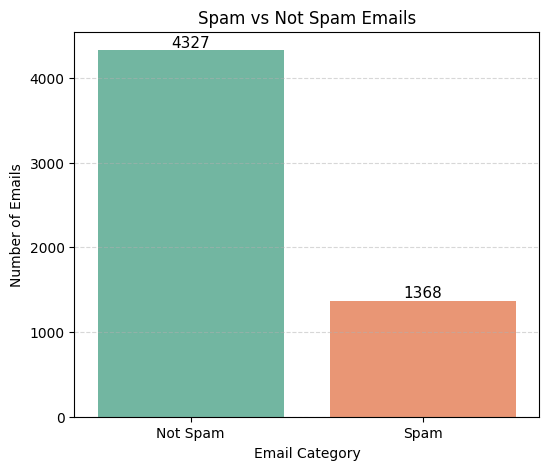


Part 1 Completed Successfully.


In [2]:
# ==========================================================
# PART 1 : DATA LOADING, PREPROCESSING & EDA
# ==========================================================

# Install Required Library
!pip -q install wordcloud

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

# ==========================================================
# UPLOAD DATASET
# ==========================================================

uploaded = files.upload()

# ==========================================================
# READ DATASET
# ==========================================================

df = pd.read_csv(next(iter(uploaded)))

# ==========================================================
# DISPLAY FIRST FIVE ROWS
# ==========================================================

print("\nFirst Five Rows")
display(df.head())

# ==========================================================
# DATASET INFORMATION
# ==========================================================

print("\nDataset Information")
df.info()

# ==========================================================
# DATASET SHAPE
# ==========================================================

print("\nDataset Shape")
print(df.shape)

# ==========================================================
# COLUMN NAMES
# ==========================================================

print("\nColumn Names")
print(df.columns)

# ==========================================================
# RENAME COLUMNS (Optional)
# ==========================================================

df.columns = ["text","spam"]

# ==========================================================
# CHECK MISSING VALUES
# ==========================================================

print("\nMissing Values")
print(df.isnull().sum())

# Remove Missing Values

df.dropna(inplace=True)

# ==========================================================
# CHECK DUPLICATE VALUES
# ==========================================================

print("\nDuplicate Rows")

print(df.duplicated().sum())

# Remove Duplicates

df.drop_duplicates(inplace=True)

# ==========================================================
# DATASET AFTER CLEANING
# ==========================================================

print("\nDataset Shape After Cleaning")

print(df.shape)

# ==========================================================
# DATA TYPES
# ==========================================================

print("\nData Types")

print(df.dtypes)

# ==========================================================
# TARGET VARIABLE COUNT
# ==========================================================

print("\nSpam Value Counts")

print(df["spam"].value_counts())

# ==========================================================
# BASIC STATISTICS
# ==========================================================

print("\nDataset Statistics")

display(df.describe())

# ==========================================================
# ADD EMAIL LENGTH COLUMN
# ==========================================================

df["Email_Length"] = df["text"].apply(len)

print("\nDataset with Email Length")

display(df.head())

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X = df["text"]

y = df["spam"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("\nTraining Samples :",len(X_train))
print("Testing Samples  :",len(X_test))

# ==========================================================
# GRAPH 1 : CLASS DISTRIBUTION
# ==========================================================

plt.figure(figsize=(6,5))

ax = sns.countplot(

    x="spam",
    data=df,
    palette="Set2"

)

plt.title("Spam vs Not Spam Emails")

plt.xlabel("Email Category")

plt.ylabel("Number of Emails")

ax.set_xticklabels(["Not Spam","Spam"])

for p in ax.patches:

    ax.annotate(

        str(int(p.get_height())),

        (p.get_x()+p.get_width()/2.,p.get_height()),

        ha="center",

        va="bottom",

        fontsize=11

    )

plt.grid(axis="y",linestyle="--",alpha=0.5)

plt.show()

# ==========================================================
# END OF PART 1
# ==========================================================

print("\nPart 1 Completed Successfully.")

MODEL TRAINING
Dummy Classifier
Accuracy : 0.7594
--------------------------------------------------
Multinomial Naive Bayes
Accuracy : 0.9833
--------------------------------------------------
Complement Naive Bayes
Accuracy : 0.9824
--------------------------------------------------
Logistic Regression
Accuracy : 0.9868
--------------------------------------------------
Linear SVC
Accuracy : 0.9939
--------------------------------------------------

Accuracy Comparison Table


,Model,Accuracy
0,Dummy Classifier,0.759438
1,Multinomial Naive Bayes,0.983319
2,Complement Naive Bayes,0.982441
3,Logistic Regression,0.986831
4,Linear SVC,0.993854



Best Model : Linear SVC

Model Accuracy saved successfully.


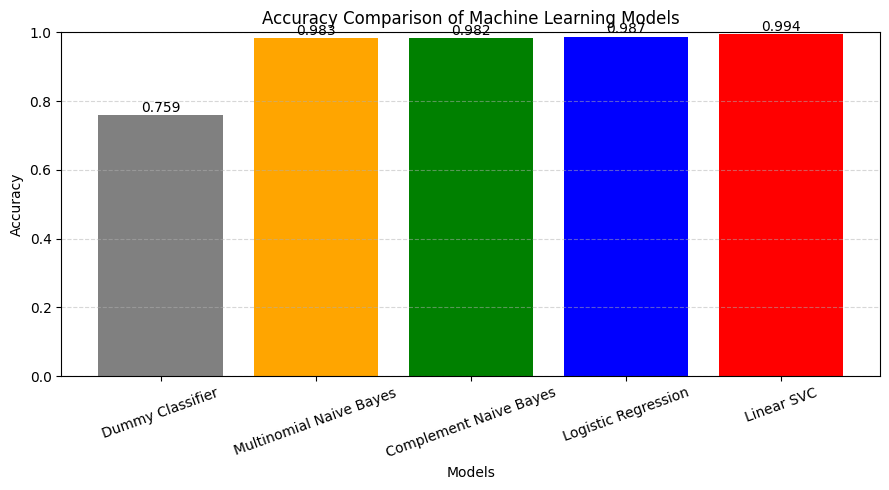


Part 2 Completed Successfully.


In [3]:
# ==========================================================
# PART 2 : TF-IDF + MODEL TRAINING
# ==========================================================

# Import Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# CREATE TF-IDF VECTORIZER
# ==========================================================

tfidf = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    max_features=5000
)

# ==========================================================
# DEFINE MODELS
# ==========================================================

models = {

    "Dummy Classifier":
    DummyClassifier(strategy="most_frequent"),

    "Multinomial Naive Bayes":
    MultinomialNB(),

    "Complement Naive Bayes":
    ComplementNB(),

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Linear SVC":
    LinearSVC()

}

# ==========================================================
# TRAIN MODELS
# ==========================================================

accuracy_list = []

trained_models = {}

print("="*60)
print("MODEL TRAINING")
print("="*60)

for model_name, model in models.items():

    pipeline = Pipeline([

        ("TF-IDF", tfidf),

        ("Classifier", model)

    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    trained_models[model_name] = pipeline

    accuracy_list.append(accuracy)

    print(model_name)
    print("Accuracy :", round(accuracy,4))
    print("-"*50)

# ==========================================================
# CREATE RESULT TABLE
# ==========================================================

results = pd.DataFrame({

    "Model": list(models.keys()),

    "Accuracy": accuracy_list

})

print("\nAccuracy Comparison Table")

display(results)

# ==========================================================
# FIND BEST MODEL
# ==========================================================

best_model_name = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_model = trained_models[best_model_name]

print("\nBest Model :", best_model_name)

# ==========================================================
# SAVE RESULT TABLE
# ==========================================================

results.to_csv("Model_Accuracy.csv", index=False)

print("\nModel Accuracy saved successfully.")

# ==========================================================
# GRAPH : MODEL ACCURACY COMPARISON
# ==========================================================

plt.figure(figsize=(9,5))

bars = plt.bar(
    results["Model"],
    results["Accuracy"],
    color=[
        "gray",
        "orange",
        "green",
        "blue",
        "red"
    ]
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.xticks(rotation=20)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.01,
        f"{height:.3f}",
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

print("\nPart 2 Completed Successfully.")

MODEL EVALUATION
Accuracy      : 0.9939
Precision     : 0.9926
Recall        : 0.9818
Macro F1      : 0.9916
Weighted F1   : 0.9938


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Not Spam       0.99      1.00      1.00       865
        Spam       0.99      0.98      0.99       274

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139


Confusion Matrix
[[863   2]
 [  5 269]]

Evaluation results saved successfully.


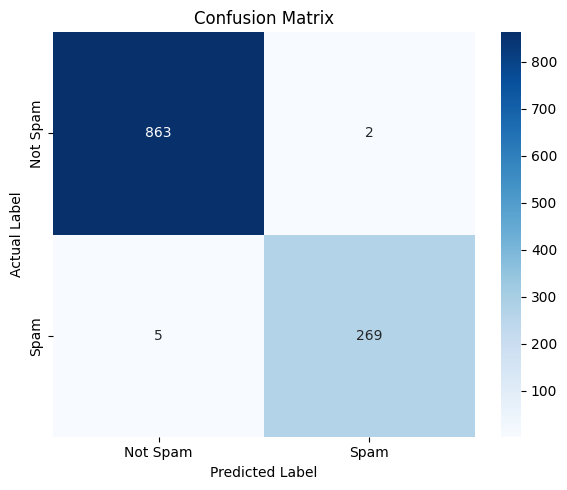


Part 3 Completed Successfully.


In [4]:
# ==========================================================
# PART 3 : MODEL EVALUATION
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# PREDICT USING BEST MODEL
# ==========================================================

y_pred = best_model.predict(X_test)

# ==========================================================
# EVALUATION METRICS
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("="*60)
print("MODEL EVALUATION")
print("="*60)

print("Accuracy      :", round(accuracy,4))
print("Precision     :", round(precision,4))
print("Recall        :", round(recall,4))
print("Macro F1      :", round(macro_f1,4))
print("Weighted F1   :", round(weighted_f1,4))

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Spam","Spam"]
))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

# ==========================================================
# SAVE EVALUATION RESULTS
# ==========================================================

evaluation = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1",
        "Weighted F1"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        macro_f1,
        weighted_f1
    ]

})

evaluation.to_csv("Evaluation_Results.csv", index=False)

print("\nEvaluation results saved successfully.")

# ==========================================================
# GRAPH : CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Spam","Spam"],
    yticklabels=["Not Spam","Spam"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.tight_layout()

plt.show()

print("\nPart 3 Completed Successfully.")

EMAIL PREDICTION RESULTS

Email 1
--------------------------------------------------
Congratulations! You have won a free iPhone. Click the link now to claim your reward.
Prediction : Spam

Email 2
--------------------------------------------------
Dear Student, tomorrow's class starts at 9:00 AM. Please attend the lecture.
Prediction : Not Spam

Email 3
--------------------------------------------------
Limited period offer! Buy one get one free. Visit our website today.
Prediction : Spam

Email 4
--------------------------------------------------
Your bank account verification is pending. Login immediately to avoid suspension.
Prediction : Spam

Email 5
--------------------------------------------------
Meeting has been scheduled for Friday at 2 PM. Kindly be present.
Prediction : Not Spam


AUTOMATIC RESPONSE

Email 1
Status : Spam Email
Action : Moved to Spam Folder
Reply  : No reply generated.

Email 2
Status : Genuine Email
Action : Delivered to Inbox
Reply  :
Thank you for your 

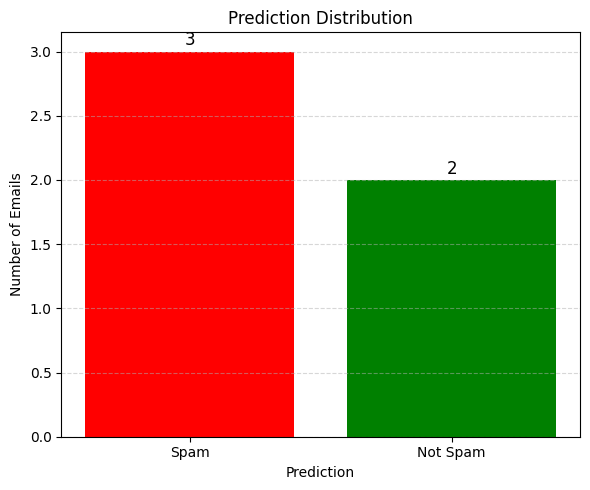



PROJECT COMPLETED SUCCESSFULLY
Dataset Used        : Spam Email Dataset
Feature             : TF-IDF
Algorithms Used     :
1. Dummy Classifier
2. Multinomial Naive Bayes
3. Complement Naive Bayes
4. Logistic Regression
5. Linear SVC

Evaluation Metrics :
✔ Accuracy
✔ Precision
✔ Recall
✔ Macro F1 Score
✔ Weighted F1 Score

Generated Files :
✔ Model_Accuracy.csv
✔ Evaluation_Results.csv
✔ Prediction_Result.csv

Graphs Generated :
✔ Part 1 : Class Distribution
✔ Part 2 : Accuracy Comparison
✔ Part 3 : Confusion Matrix
✔ Part 4 : Prediction Distribution

THANK YOU


In [5]:
# ==========================================================
# PART 4 : EMAIL PREDICTION & FINAL RESULT
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# SAMPLE EMAILS
# ==========================================================

sample_emails = [

    "Congratulations! You have won a free iPhone. Click the link now to claim your reward.",

    "Dear Student, tomorrow's class starts at 9:00 AM. Please attend the lecture.",

    "Limited period offer! Buy one get one free. Visit our website today.",

    "Your bank account verification is pending. Login immediately to avoid suspension.",

    "Meeting has been scheduled for Friday at 2 PM. Kindly be present."

]

# ==========================================================
# PREDICT EMAIL CLASS
# ==========================================================

predictions = best_model.predict(sample_emails)

# ==========================================================
# DISPLAY RESULTS
# ==========================================================

print("="*70)
print("EMAIL PREDICTION RESULTS")
print("="*70)

prediction_labels = []

for i in range(len(sample_emails)):

    if predictions[i] == 1:
        label = "Spam"
    else:
        label = "Not Spam"

    prediction_labels.append(label)

    print("\nEmail", i+1)
    print("-"*50)
    print(sample_emails[i])
    print("Prediction :", label)

# ==========================================================
# AUTOMATIC EMAIL RESPONSE
# ==========================================================

print("\n")
print("="*70)
print("AUTOMATIC RESPONSE")
print("="*70)

for i in range(len(sample_emails)):

    print("\nEmail", i+1)

    if predictions[i] == 1:

        print("Status : Spam Email")
        print("Action : Moved to Spam Folder")
        print("Reply  : No reply generated.")

    else:

        print("Status : Genuine Email")
        print("Action : Delivered to Inbox")
        print("Reply  :")
        print("Thank you for your email. We have received your message and will reply shortly.")

# ==========================================================
# SAVE PREDICTION RESULTS
# ==========================================================

prediction_df = pd.DataFrame({

    "Email": sample_emails,
    "Prediction": prediction_labels

})

prediction_df.to_csv("Prediction_Result.csv", index=False)

print("\nPrediction_Result.csv saved successfully.")

# ==========================================================
# GRAPH : PREDICTION DISTRIBUTION
# ==========================================================

spam_count = prediction_labels.count("Spam")
not_spam_count = prediction_labels.count("Not Spam")

plt.figure(figsize=(6,5))

bars = plt.bar(

    ["Spam","Not Spam"],

    [spam_count, not_spam_count],

    color=["red","green"]

)

plt.title("Prediction Distribution")

plt.xlabel("Prediction")

plt.ylabel("Number of Emails")

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x()+bar.get_width()/2,

        height+0.05,

        str(height),

        ha="center",

        fontsize=12

    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n")
print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

print("Dataset Used        : Spam Email Dataset")
print("Feature             : TF-IDF")
print("Algorithms Used     :")
print("1. Dummy Classifier")
print("2. Multinomial Naive Bayes")
print("3. Complement Naive Bayes")
print("4. Logistic Regression")
print("5. Linear SVC")

print("\nEvaluation Metrics :")
print("✔ Accuracy")
print("✔ Precision")
print("✔ Recall")
print("✔ Macro F1 Score")
print("✔ Weighted F1 Score")

print("\nGenerated Files :")
print("✔ Model_Accuracy.csv")
print("✔ Evaluation_Results.csv")
print("✔ Prediction_Result.csv")

print("\nGraphs Generated :")
print("✔ Part 1 : Class Distribution")
print("✔ Part 2 : Accuracy Comparison")
print("✔ Part 3 : Confusion Matrix")
print("✔ Part 4 : Prediction Distribution")

print("\nTHANK YOU")